# Crawling & Analisis Data Polutan Udara di Kabupaten Lamongan

Nama :Dedy Nurohim

NIM :240411100115

Mata Kuliah : Pengantar Sains Data (PSD)

## Latar Belakang

Kabupaten Lamongan merupakan salah satu kabupaten di Provinsi Jawa Timur yang memiliki karakteristik wilayah yang beragam, meliputi sektor pertanian (padi, jagung, dan tambak ikan), peternakan, perikanan, serta aktivitas industri dan perdagangan yang terus berkembang. Beberapa industri yang beroperasi di Lamongan antara lain industri pengolahan hasil perikanan, industri makanan dan minuman, industri kayu, serta pembangkit listrik. Selain itu, wilayah Lamongan dilalui jalur transportasi utama Pantai Utara (Pantura) Jawa yang memiliki intensitas lalu lintas kendaraan berat (truk dan bus) yang cukup tinggi. Sektor pertanian yang luas, khususnya lahan sawah, juga menjadi sumber emisi metana (CH4) yang signifikan, sementara aktivitas pembakaran lahan dan sampah berkontribusi pada peningkatan konsentrasi CO dan HCHO di atmosfer. Oleh karena itu, pemantauan konsentrasi polutan udara seperti Karbon Monoksida (CO), Nitrogen Dioksida (NO2), Formaldehida (HCHO), Ozon troposferik (O3), Sulfur Dioksida (SO2), dan Metana (CH4) menjadi penting untuk memahami kondisi kualitas udara di wilayah Lamongan dari waktu ke waktu.


## 1. Business Understanding

### a. Tujuan

Tugas ini bertujuan untuk mengetahui sumber-sumber polutan serta kondisi/kualitas udara di wilayah Kabupaten Lamongan, melalui proses crawling data satelit untuk enam jenis polutan (CO, NO2, HCHO, O3, SO2, CH4), eksplorasi data (data understanding), serta visualisasi data time series selama kurun waktu minimal satu tahun sebelum 31 Agustus 2026.

### b. Manfaat

Manfaat yang diharapkan dari tugas ini antara lain:

1. Memberikan gambaran mengenai pola dan tren konsentrasi masing-masing polutan di wilayah Lamongan sepanjang waktu.
2. Membantu mengidentifikasi kemungkinan sumber dominan tiap polutan berdasarkan karakteristik wilayah Lamongan (pertanian, peternakan, perikanan, transportasi, dan industri).
3. Menjadi bahan evaluasi awal terkait kondisi kualitas udara di wilayah tersebut.
4. Menjadi dasar bagi analisis lanjutan (preprocessing dan pemodelan) pada tahap berikutnya.
5. Melatih kemampuan pengambilan data dari sumber data satelit (remote sensing) serta praktik data understanding untuk data time series lingkungan.

### c. Kemungkinan Sumber Masing-Masing Polutan

| Polutan | Deskripsi Singkat | Kemungkinan Sumber di Lamongan |
|---|---|---|
| **CO** (Karbon Monoksida) | Gas hasil pembakaran tidak sempurna bahan bakar fosil | Emisi kendaraan bermotor di jalur Pantura, pembakaran lahan pertanian/sampah, aktivitas industri pengolahan, kebakaran lahan |
| **NO2** (Nitrogen Dioksida) | Gas pencemar hasil pembakaran suhu tinggi | Emisi kendaraan berat di jalur Pantura, aktivitas industri dan pembangkit listrik, pembakaran bahan bakar fosil |
| **HCHO** (Formaldehida) | Senyawa organik volatil (VOC) hasil oksidasi hidrokarbon di atmosfer | Pembakaran lahan pertanian/biomassa, industri kayu dan pengolahan, emisi kendaraan, oksidasi VOC alami dari vegetasi pertanian yang luas |
| **O3** (Ozon troposferik) | Polutan sekunder, terbentuk dari reaksi fotokimia | Reaksi fotokimia antara NOx dan VOC dengan bantuan sinar matahari, terkait emisi kendaraan Pantura dan lahan pertanian yang luas |
| **SO2** (Sulfur Dioksida) | Gas hasil pembakaran bahan bakar yang mengandung sulfur | Pembangkit listrik, industri pengolahan, serta pembakaran bahan bakar fosil pada kendaraan dan aktivitas industri di Lamongan |
| **CH4** (Metana) | Gas rumah kaca, salah satu VOC utama | Lahan persawahan yang sangat luas (Lamongan adalah penghasil padi terbesar Jawa Timur), peternakan sapi dan unggas, tempat pembuangan akhir (TPA) sampah, serta tambak ikan |

### d. Deskripsi Data

Data yang digunakan pada tugas ini bersumber dari citra satelit **Sentinel-5P TROPOMI** (Tropospheric Monitoring Instrument) yang dikelola oleh European Space Agency (ESA) di bawah program Copernicus, diakses melalui platform **Copernicus Data Space Ecosystem** menggunakan pustaka `openeo` pada Python dengan koleksi data `SENTINEL_5P_L2`.

Setiap band (CO, NO2, HCHO, O3, SO2, CH4) merepresentasikan nilai kolom vertikal (*total column density*) gas tersebut di atmosfer, pada satuan **mol/m²**, dengan resolusi spasial berkisar antara 5.5×3.5 km hingga 7×7 km tergantung jenis produknya, dan resolusi temporal harian (satu kali lintasan per hari untuk wilayah tertentu, dengan kemungkinan data kosong pada beberapa hari akibat tutupan awan).

Perlu dicatat bahwa pada implementasi openEO/Sentinel Hub API saat ini, satu permintaan data (`load_collection`) hanya dapat memuat **satu band/jenis polutan** untuk koleksi Sentinel-5P L2 — sehingga proses crawling keenam polutan pada tugas ini dilakukan secara terpisah (loop) satu per satu, dan hasilnya diunduh sebagai berkas NetCDF (`.nc`) terpisah untuk masing-masing polutan.


## 2. Penentuan Wilayah Kajian (Area of Interest) Menggunakan GeoJSON.io

Wilayah kajian ditentukan menggunakan berkas **GeoJSON** berbentuk polygon yang mencakup wilayah Kabupaten Lamongan (dan sekitarnya), digambar melalui [geojson.io](https://geojson.io) kemudian disimpan sebagai berkas `.geojson` dan dibaca kembali menggunakan Python untuk membatasi wilayah pengambilan data pada tahap crawling.

In [1]:
import json

# GeoJSON wilayah kajian (Kabupaten Lamongan), digambar melalui geojson.io
# =====================================================================
# ISI KOORDINAT POLYGON DI BAWAH INI SESUAI WILAYAH LAMONGAN
# Format: [bujur, lintang] yaitu [longitude, latitude]
# Cara mudah: buka https://geojson.io -> gambar polygon -> copy koordinat
# =====================================================================

aoi_geojson = {
    "type": "FeatureCollection",
    "features": [
        {
            "type": "Feature",
            "properties": {},
            "geometry": {
                "type": "Polygon",
                "coordinates": [
          [
            [
              112.1808803,
              -6.8897834
            ],
            [
              112.1846172,
              -7.3045942
            ],
            [
              112.4308907,
              -7.2950522
            ],
            [
              112.4367917,
              -6.8651238
            ],
            [
              112.2876554,
              -6.8718541
            ],
            [
              112.1808803,
              -6.8897834
            ]
          ]
        ]
      }
    }
  ]
}

with open("aoi_lamongan.geojson", "w") as f:
    json.dump(aoi_geojson, f, indent=2)

print("Berkas aoi_lamongan.geojson berhasil disimpan.")


Berkas aoi_lamongan.geojson berhasil disimpan.


In [2]:
with open("aoi_lamongan.geojson", "r") as f:
    aoi_geojson = json.load(f)

polygon_coords = aoi_geojson["features"][0]["geometry"]["coordinates"][0]
lons = [c[0] for c in polygon_coords]
lats = [c[1] for c in polygon_coords]

bbox = {
    "west": min(lons),
    "south": min(lats),
    "east": max(lons),
    "north": max(lats)
}

print("Bounding box wilayah kajian (Lamongan):")
print(bbox)

Bounding box wilayah kajian (Lamongan):
{'west': 112.1808803, 'south': -7.3045942, 'east': 112.4367917, 'north': -6.8651238}


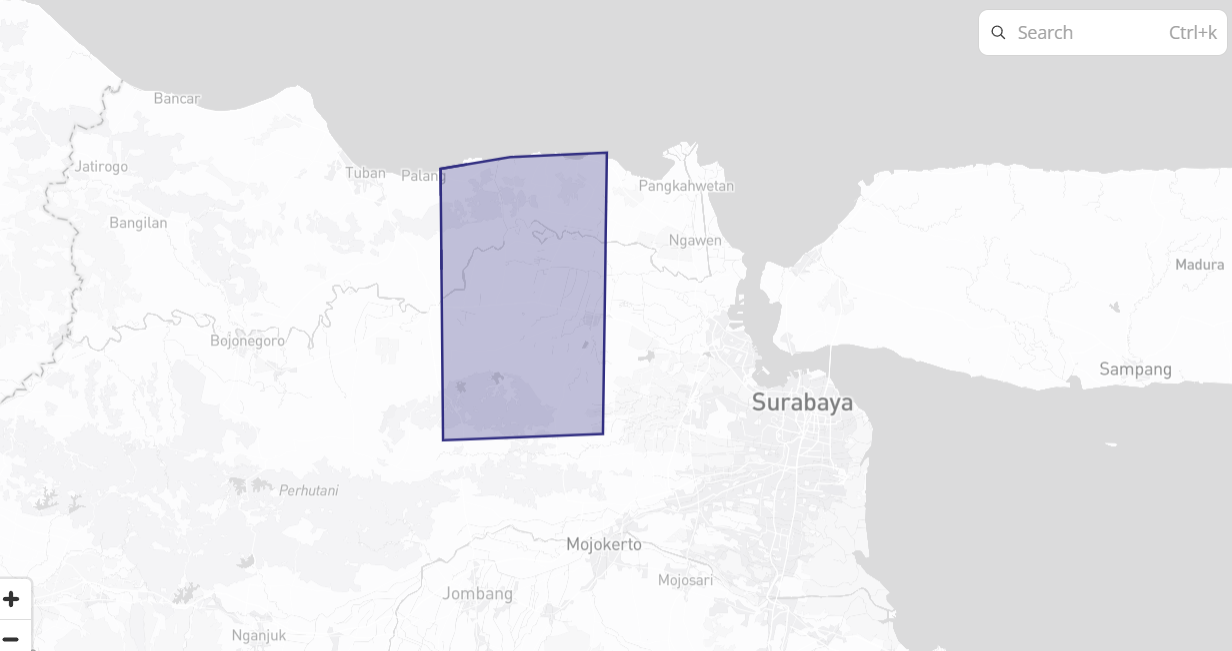

## 3. Data Collection (Crawling Data)

### a. Instalasi Library dan Koneksi ke Copernicus Data Space Ecosystem

In [3]:
pip install openeo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.2/349.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.2 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [4]:
import openeo
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=ZQII-ZLIT 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.


### b. Crawling Enam Polutan (CO, NO2, HCHO, O3, SO2, CH4)

Rentang waktu pengamatan ditentukan minimal satu tahun hingga tanggal 31 Agustus 2026, sesuai ketentuan tugas. Karena satu permintaan hanya dapat memuat satu band, proses crawling dilakukan melalui perulangan (`loop`) untuk setiap polutan, dan masing-masing hasil diunduh sebagai berkas NetCDF terpisah.

**Catatan:** apabila notebook ini dijalankan sebelum tanggal 31 Agustus 2026, data yang tersedia hanya akan mencakup tanggal terbaru yang sudah direkam satelit pada saat crawling dijalankan. Notebook perlu dijalankan ulang mendekati/sesudah tanggal tersebut agar rentang data benar-benar lengkap.

In [5]:
pollutants = ["CO", "NO2", "HCHO", "O3", "SO2", "CH4"]

start_date = "2025-08-25"
end_date = "2026-08-31"

for pol in pollutants:
    cube = connection.load_collection(
        "SENTINEL_5P_L2",
        temporal_extent=[start_date, end_date],
        spatial_extent=bbox,
        bands=[pol],
    )
    cube_daily = cube.aggregate_temporal_period(reducer="mean", period="day")
    cube_daily.execute_batch(title=f"{pol} in Lamongan", outputfile=f"{pol}_Lamongan.nc")
    print(f"Selesai mengunduh data {pol} -> {pol}_Lamongan.nc")

0:00:00 Job 'j-2608251205154f2cb9251c371cd9cc76': send 'start'
0:00:04 Job 'j-2608251205154f2cb9251c371cd9cc76': queued (progress 0%)
0:00:09 Job 'j-2608251205154f2cb9251c371cd9cc76': queued (progress 0%)
0:00:16 Job 'j-2608251205154f2cb9251c371cd9cc76': queued (progress 0%)
0:00:24 Job 'j-2608251205154f2cb9251c371cd9cc76': queued (progress 0%)
0:00:34 Job 'j-2608251205154f2cb9251c371cd9cc76': queued (progress 0%)
0:00:47 Job 'j-2608251205154f2cb9251c371cd9cc76': queued (progress 0%)
0:01:03 Job 'j-2608251205154f2cb9251c371cd9cc76': running (progress N/A)
0:01:22 Job 'j-2608251205154f2cb9251c371cd9cc76': running (progress N/A)
0:01:46 Job 'j-2608251205154f2cb9251c371cd9cc76': running (progress N/A)
0:02:16 Job 'j-2608251205154f2cb9251c371cd9cc76': running (progress N/A)
0:02:54 Job 'j-2608251205154f2cb9251c371cd9cc76': running (progress N/A)
0:03:41 Job 'j-2608251205154f2cb9251c371cd9cc76': finished (progress 100%)
Selesai mengunduh data CO -> CO_Lamongan.nc
0:00:00 Job 'j-260825120906

Proses pengambilan data dapat dipantau pada halaman https://editor.openeo.org/?server=https%3A%2F%2Fopeneo.dataspace.copernicus.eu%2Fopeneo%2F1.2, yang menampilkan status job serta dataset yang sedang diproses untuk masing-masing polutan.

## 4. Data Understanding

### a. Membaca Seluruh Berkas NetCDF dan Menyimpan ke CSV

Setiap berkas NetCDF hasil crawling dibaca, dihitung rata-rata nilai per hari untuk seluruh grid dalam wilayah kajian, kemudian disimpan ke dalam berkas CSV terpisah untuk masing-masing polutan.

In [6]:
!pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 88.0 MB/s eta 0:00:00


In [7]:
import netCDF4
import numpy as np
import pandas as pd

def read_daily_mean(band_name, filename):
    ds = netCDF4.Dataset(filename)

    values = ds.variables[band_name][:]
    time = ds.variables["t"][:]
    time_units = ds.variables["t"].units

    dates = netCDF4.num2date(
        time,
        units=time_units
    )

    daily_dates = [
        d.strftime("%Y-%m-%d")
        for d in dates
    ]

    daily_mean = []

    for i in range(len(values)):

        # Ambil satu hari
        data_harian = values[i]

        # Hitung mean dengan mengabaikan masked value
        mean_value = np.ma.mean(data_harian)

        # Ubah masked menjadi NaN
        if np.ma.is_masked(mean_value):
            mean_value = np.nan
        else:
            mean_value = float(mean_value)

        daily_mean.append(mean_value)

    df = pd.DataFrame({
        "date": daily_dates,
        band_name: daily_mean
    })

    df["date"] = pd.to_datetime(df["date"])

    # Pastikan benar-benar numeric
    df[band_name] = pd.to_numeric(
        df[band_name],
        errors="coerce"
    )

    return df

# Membaca semua data polutan
dataframes = {}

for pol in pollutants:
    df_pol = read_daily_mean(
        pol,
        f"{pol}_Lamongan.nc"
    )

    dataframes[pol] = df_pol

    print(
        f"{pol}: {df_pol.shape[0]} baris data berhasil dibaca"
    )


# ==========================================
# GABUNGKAN LANGSUNG BERDASARKAN TANGGAL
# ==========================================

merged_df = dataframes[pollutants[0]][["date"]].copy()

for pol in pollutants:
    merged_df = merged_df.merge(
        dataframes[pol][["date", pol]],
        on="date",
        how="outer"
    )

# Urutkan berdasarkan tanggal
merged_df = merged_df.sort_values(
    "date"
).reset_index(drop=True)


# ==========================================
# SIMPAN HANYA SATU CSV
# ==========================================

merged_df.to_csv(
    "all_polutan_Lamongan_timeseries.csv",
    index=False
)

print("\nData berhasil disimpan!")
print("Nama file: all_polutan_Lamongan_timeseries.csv")
print("Jumlah baris:", len(merged_df))
print("Kolom:", merged_df.columns.tolist())

display(merged_df.head())

CO: 366 baris data berhasil dibaca
NO2: 364 baris data berhasil dibaca
HCHO: 362 baris data berhasil dibaca
O3: 362 baris data berhasil dibaca
SO2: 362 baris data berhasil dibaca
CH4: 219 baris data berhasil dibaca

Data berhasil disimpan!
Nama file: all_polutan_Lamongan_timeseries.csv
Jumlah baris: 366
Kolom: ['date', 'CO', 'NO2', 'HCHO', 'O3', 'SO2', 'CH4']


,date,CO,NO2,HCHO,O3,SO2,CH4
0,2025-08-25,0.031745,0.000031,0.000163,0.117002,0.000349,NaN
1,2025-08-26,0.034966,0.000065,0.000159,0.115598,-0.000009,NaN
2,2025-08-27,0.028168,0.000029,0.000150,0.116313,0.000113,NaN
3,2025-08-28,0.028285,NaN,0.000117,0.116150,NaN,NaN
4,2025-08-29,0.030444,0.000052,0.000162,0.113017,0.000027,NaN


### b. Mengecek Struktur dan Isi Data

Untuk masing-masing polutan, diperiksa struktur data (tipe kolom, jumlah baris) serta beberapa baris pertama untuk memastikan hasil crawling sesuai yang diharapkan.

In [8]:
print("=== Struktur Data Polutan Lamongan ===")
merged_df.info()

print("\n=== Ukuran Dataset ===")
print("Jumlah baris :", merged_df.shape[0])
print("Jumlah kolom :", merged_df.shape[1])

print("\n=== Nama Kolom ===")
print(merged_df.columns.tolist())

print("\n=== 5 Data Pertama ===")
display(merged_df.head())

print("\n=== 5 Data Terakhir ===")
display(merged_df.tail())

=== Struktur Data Polutan Lamongan ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    366 non-null    datetime64[ns]
 1   CO      294 non-null    float64       
 2   NO2     294 non-null    float64       
 3   HCHO    334 non-null    float64       
 4   O3      362 non-null    float64       
 5   SO2     326 non-null    float64       
 6   CH4     47 non-null     float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 20.1 KB

=== Ukuran Dataset ===
Jumlah baris : 366
Jumlah kolom : 7

=== Nama Kolom ===
['date', 'CO', 'NO2', 'HCHO', 'O3', 'SO2', 'CH4']

=== 5 Data Pertama ===


,date,CO,NO2,HCHO,O3,SO2,CH4
0,2025-08-25,0.031745,0.000031,0.000163,0.117002,0.000349,NaN
1,2025-08-26,0.034966,0.000065,0.000159,0.115598,-0.000009,NaN
2,2025-08-27,0.028168,0.000029,0.000150,0.116313,0.000113,NaN
3,2025-08-28,0.028285,NaN,0.000117,0.116150,NaN,NaN
4,2025-08-29,0.030444,0.000052,0.000162,0.113017,0.000027,NaN



=== 5 Data Terakhir ===


,date,CO,NO2,HCHO,O3,SO2,CH4
361,2026-08-21,0.027828,0.000044,0.000109,0.122303,0.000090,1896.705444
362,2026-08-22,0.030738,0.000045,0.000195,0.121145,-0.000021,NaN
363,2026-08-23,0.033989,0.000049,0.000250,0.120597,-0.000110,NaN
364,2026-08-24,0.030894,0.000050,0.000131,0.120291,0.000058,1859.697266
365,2026-08-25,0.032329,0.000039,0.000213,0.119633,0.000006,1887.234766


### c. Mengecek Missing Value

Missing value pada data Sentinel-5P umumnya terjadi akibat tutupan awan (*cloud cover*) yang menghalangi pengukuran satelit, sehingga sensor tidak mencatat nilai valid pada tanggal tertentu.

In [9]:
print(f"{'Polutan':<8}{'Jumlah Baris':<15}{'Missing Value':<15}{'Persentase':<10}")

for pol in pollutants:
    n_total = len(merged_df)
    n_missing = merged_df[pol].isna().sum()
    pct = n_missing / n_total * 100 if n_total > 0 else 0
    print(f"{pol:<8}{n_total:<15}{n_missing:<15}{pct:.2f}%")

Polutan Jumlah Baris   Missing Value  Persentase
CO      366            72             19.67%
NO2     366            72             19.67%
HCHO    366            32             8.74%
O3      366            4              1.09%
SO2     366            40             10.93%
CH4     366            319            87.16%


### d. Mengecek Data Aneh / Outlier

Statistik deskriptif dan deteksi outlier menggunakan metode *Interquartile Range* (IQR) digunakan untuk mengidentifikasi nilai yang berada jauh di luar sebaran normal data, termasuk mengecek kewajaran nilai (apakah terdapat nilai negatif ekstrem yang tidak wajar secara fisis).

In [10]:
summary_rows = []

for pol in pollutants:

    # Ambil kolom polutan dari dataset utama
    series = merged_df[pol].dropna()

    # Kuartil
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)

    # IQR
    IQR = Q3 - Q1

    # Batas outlier
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Jumlah outlier
    n_outliers = (
        (series < lower_bound) |
        (series > upper_bound)
    ).sum()

    summary_rows.append({
        "Polutan": pol,
        "Min": series.min(),
        "Max": series.max(),
        "Mean": series.mean(),
        "Std": series.std(),
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Batas Bawah": lower_bound,
        "Batas Atas": upper_bound,
        "Jumlah Outlier IQR": n_outliers
    })

summary_df = pd.DataFrame(summary_rows)

display(summary_df)

,Polutan,Min,Max,Mean,Std,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier IQR
0,CO,0.022632,0.043725,0.029684,0.003117,0.027433,0.031583,0.004150,0.021208,0.037808,2
1,NO2,0.000009,0.000075,0.000037,0.000013,0.000027,0.000046,0.000019,-0.000002,0.000074,1
2,HCHO,-0.000197,0.000424,0.000171,0.000065,0.000132,0.000206,0.000074,0.000022,0.000316,12
3,O3,0.110193,0.122715,0.115819,0.002392,0.113902,0.117361,0.003459,0.108714,0.122549,1
4,SO2,-0.000415,0.000637,0.000064,0.000129,0.000002,0.000119,0.000117,-0.000174,0.000294,23
5,CH4,1809.648600,1921.356934,1885.908595,23.334532,1869.924984,1900.781834,30.856850,1823.639708,1947.067110,1


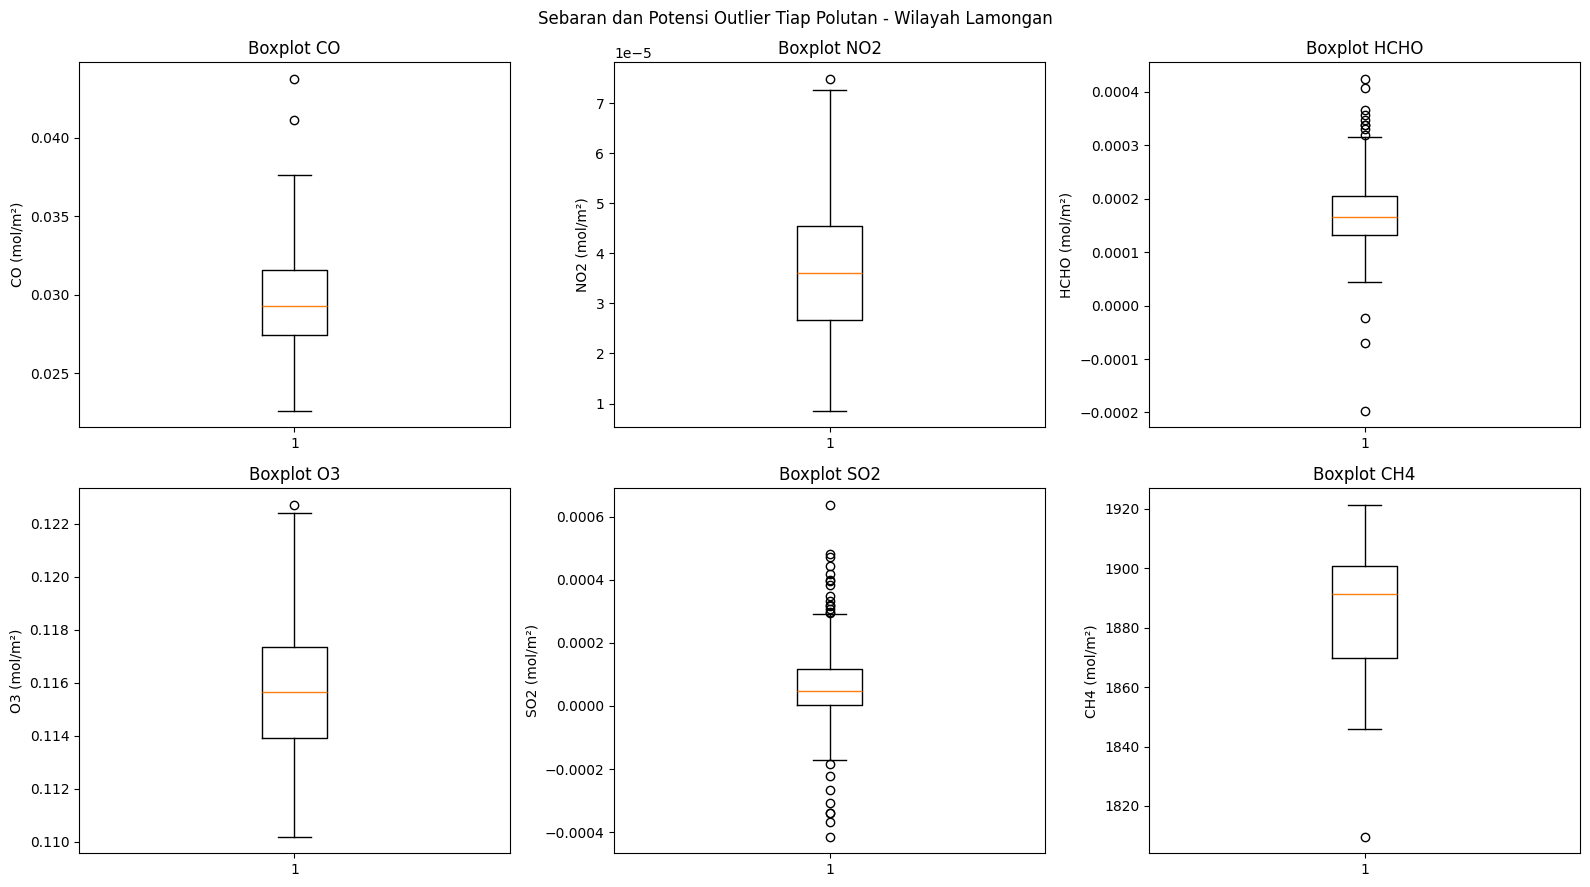

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, pol in zip(axes.flatten(), pollutants):
    ax.boxplot(
        merged_df[pol].dropna()
    )
    ax.set_title(f"Boxplot {pol}")
    ax.set_ylabel(f"{pol} (mol/m²)")

plt.suptitle(
    "Sebaran dan Potensi Outlier Tiap Polutan - Wilayah Lamongan"
)

plt.tight_layout()
plt.show()

## 5. Visualisasi Time Series

Grafik berikut menampilkan perubahan konsentrasi masing-masing polutan di wilayah Kabupaten Lamongan dari waktu ke waktu, menggunakan data harian hasil crawling (tanpa tahap pembersihan lebih lanjut, sesuai lingkup tugas ini yang berhenti pada tahap Data Understanding).

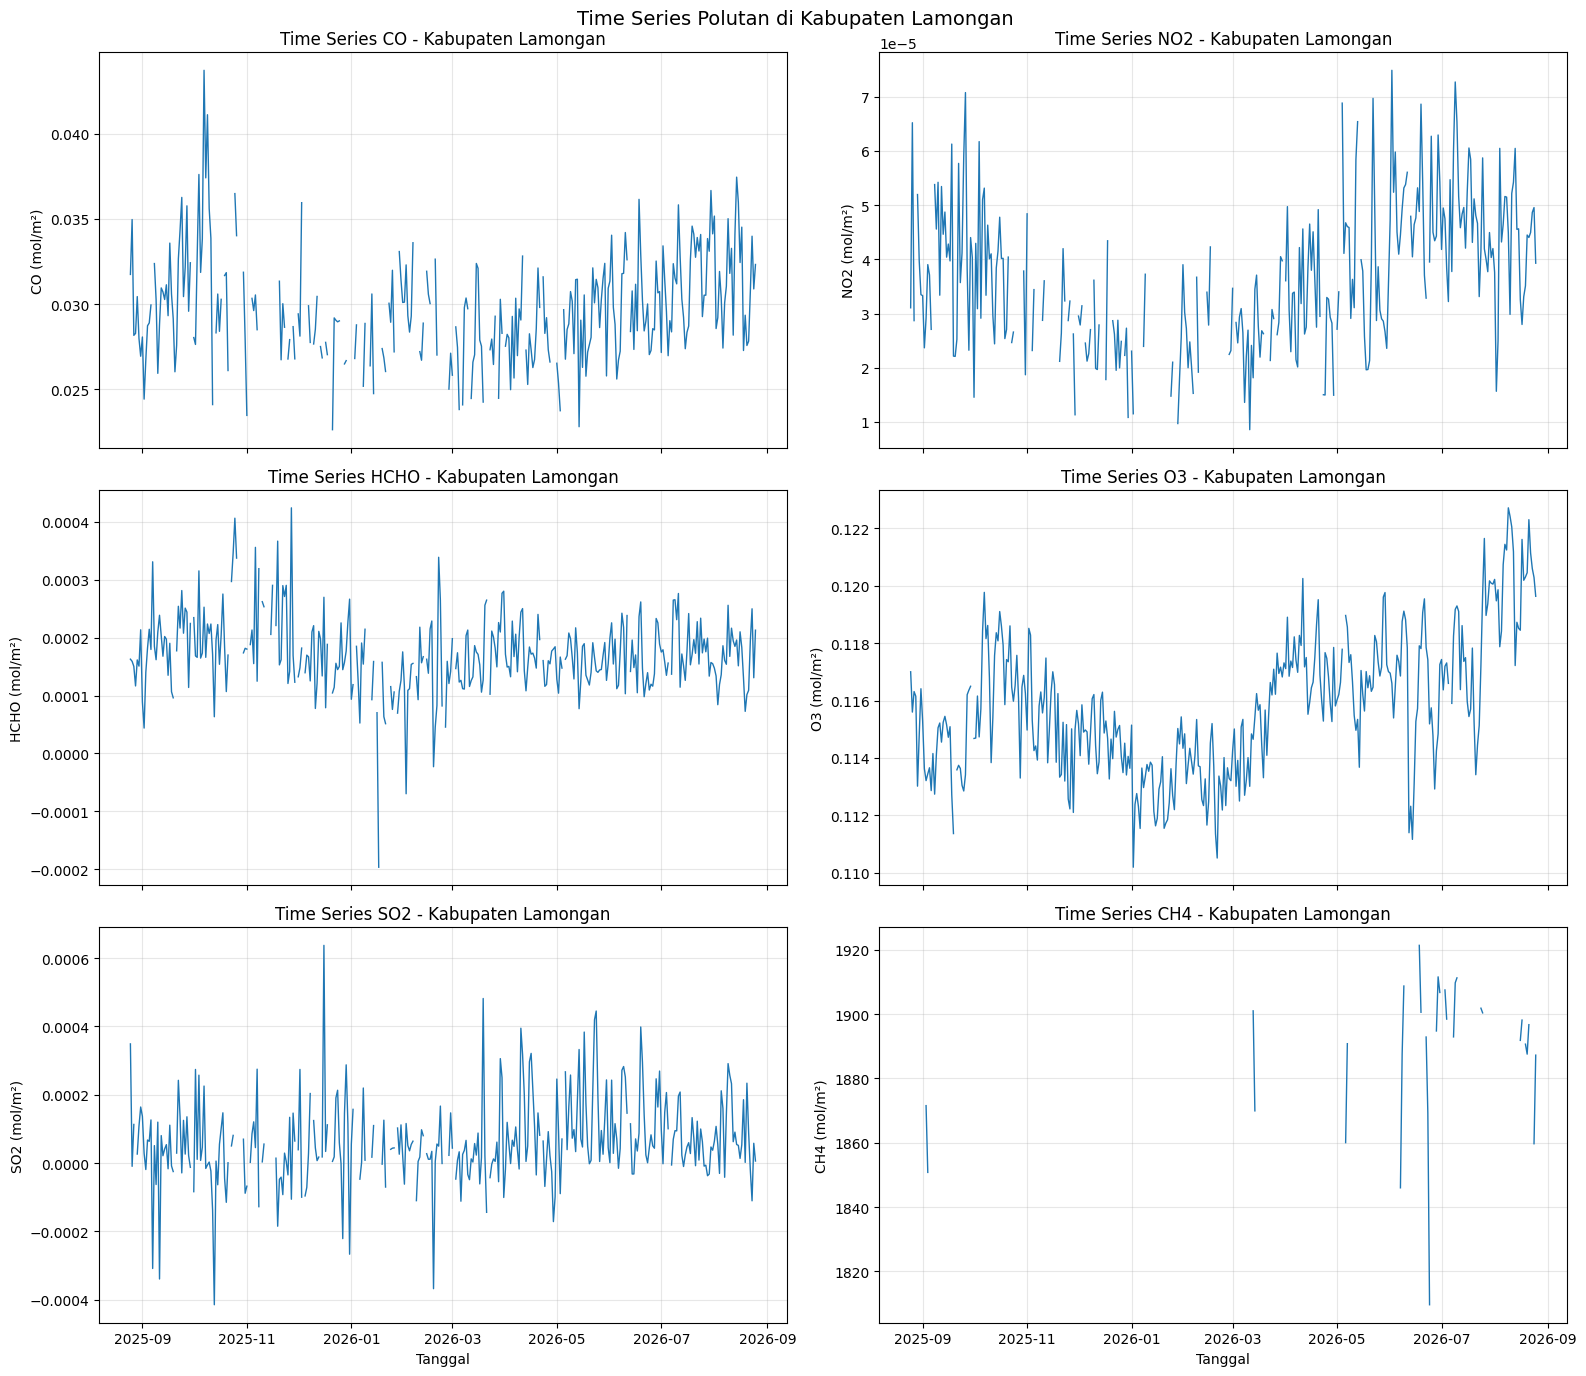

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    3, 2,
    figsize=(16, 14),
    sharex=True
)

for ax, pol in zip(axes.flatten(), pollutants):
    ax.plot(
        merged_df["date"],
        merged_df[pol],
        linewidth=1
    )
    ax.set_title(
        f"Time Series {pol} - Kabupaten Lamongan"
    )
    ax.set_ylabel(
        f"{pol} (mol/m²)"
    )
    ax.grid(alpha=0.3)

axes[-1, 0].set_xlabel("Tanggal")
axes[-1, 1].set_xlabel("Tanggal")

plt.suptitle(
    "Time Series Polutan di Kabupaten Lamongan",
    fontsize=14
)

plt.tight_layout()
plt.show()

## 6. Unduh Dataset

Dataset hasil crawling polutan udara di Kabupaten Lamongan tersedia untuk diunduh dalam format CSV. Klik tombol di bawah untuk mengunduh berkas secara langsung.


In [ ]:
# Salin CSV terbaru ke _static/ agar tersedia di HTML build
import shutil, os
csv_file = 'all_polutan_Lamongan_timeseries.csv'
static_dir = os.path.join(os.path.dirname(os.path.abspath('__file__')), '_static')
os.makedirs(static_dir, exist_ok=True)
if os.path.exists(csv_file):
    shutil.copy2(csv_file, os.path.join(static_dir, csv_file))
    print(f'CSV disalin ke _static/')


<div style="margin:20px 0;padding:20px;
background:linear-gradient(135deg,#f0f4ff,#e8f0fe);
border-radius:12px;border-left:5px solid #4285f4;
font-family:Arial,sans-serif;">

<p style="margin:0 0 6px 0;font-weight:bold;color:#1a1a1a;font-size:15px;">
Dataset Polutan Udara - Kabupaten Lamongan
</p>

<p style="margin:0 0 14px 0;color:#555;font-size:13px;">
Format CSV &nbsp;|&nbsp; Polutan: CO, NO2, HCHO, O3, SO2, CH4
</p>

<a href="_static/all_polutan_Lamongan_timeseries.csv"
   download="all_polutan_Lamongan_timeseries.csv"
   style="display:inline-block;padding:10px 24px;
   background:linear-gradient(135deg,#4285f4,#1a73e8);
   color:white;text-decoration:none;border-radius:8px;
   font-weight:bold;font-size:14px;
   box-shadow:0 2px 8px rgba(66,133,244,0.4);">
   &#11015; Download CSV
</a>

</div>


## Kesimpulan

Berdasarkan hasil tugas ini, data konsentrasi enam jenis polutan udara (CO, NO2, HCHO, O3, SO2, dan CH4) di wilayah Kabupaten Lamongan berhasil diperoleh melalui proses crawling data satelit Sentinel-5P menggunakan pustaka OpenEO, dengan wilayah kajian dibatasi menggunakan berkas GeoJSON yang digambar melalui geojson.io. Karena keterbatasan API yang hanya mengizinkan satu band per permintaan, proses crawling dilakukan secara terpisah untuk tiap polutan dan hasilnya digabungkan menjadi satu berkas CSV gabungan (`all_polutan_Lamongan_timeseries.csv`) yang mencakup periode **25 Agustus 2025 hingga 25 Agustus 2026** (366 hari).

Tahap data understanding menunjukkan bahwa missing value bervariasi antar polutan: O3 memiliki missing value paling rendah (4 hari, 1,1%), diikuti HCHO (32 hari, 8,7%), SO2 (40 hari, 10,9%), CO dan NO2 (masing-masing 72 hari, 19,7%), sedangkan CH4 memiliki missing value sangat tinggi (319 hari, 87,2%) yang kemungkinan disebabkan oleh keterbatasan cakupan produk CH4 pada wilayah lintang rendah dan tutupan awan. Missing value pada polutan lain umumnya terjadi akibat tutupan awan yang menghalangi sensor satelit.

Deteksi outlier menggunakan metode IQR menunjukkan bahwa SO2 memiliki jumlah outlier tertinggi (23 data) diikuti HCHO (12 data), yang kemungkinan mencerminkan fluktuasi emisi dari aktivitas industri dan pembakaran lahan pertanian di Lamongan. Rata-rata konsentrasi CO sebesar 0,0297 mol/m², NO2 sebesar 3,7×10⁻⁵ mol/m², dan O3 sebesar 0,1158 mol/m² mengindikasikan kondisi kualitas udara yang secara umum masih dalam batas normal namun menunjukkan pengaruh aktivitas transportasi Pantura dan pertanian.

Hasil visualisasi time series menunjukkan pola fluktuasi konsentrasi tiap polutan yang mengindikasikan potensi keterkaitan dengan karakteristik wilayah Lamongan, di antaranya aktivitas pertanian sawah yang sangat luas sebagai sumber CH4, transportasi jalur Pantura sebagai sumber dominan NO2 dan CO, serta pembakaran lahan pertanian yang berkontribusi pada lonjakan HCHO dan SO2 pada periode tertentu. Temuan ini menjadi dasar bagi tahap preprocessing (penanganan missing value dan outlier) serta pemodelan pada pertemuan berikutnya.
